# Introduction

In recent decades, the film industry has increasingly relied on pre-existing intellectual properties such as novels, comics and video games. This trend reflects a broader transformation of the industry, where studios tend to favor projects with an already established audience, thereby reducing financial risk.As a result, adaptations have become a central component of modern film production.
However, it remains unclear whether this tendency has significantly increased over time or if it is simply a perception reinforced by the prominence of major franchises. Understanding this evolution requires a rigorous statistical approach capable of quantifying uncertainty and comparing probabilities across different time periods. 

# Problem Statement

This project aims to answer the following question:

*Has the probability that a film is an adaptation of a pre-existing work increased after 2010 compared to before 2010?*

To address this question, we analyze a dataset of films and compare the proportion of adaptations across two periods: before and after 2010.

### Goal
Determine whether the probability that a film is an adaptation has increased after 2010 compared to before 2010.

### Hypotheses

- **Null hypothesis ($H_0$):**  
  $$P(\text{adapted} \mid \text{after 2010}) \leq P(\text{adapted} \mid \text{before 2010})$$

- **Alternative hypothesis ($H_1$):**  
  $$P(\text{adapted} \mid \text{after 2010}) > P(\text{adapted} \mid \text{before 2010})$$

# Why a Bayesian Approach?

A Bayesian framework is particularly well suited to this problem because we are interested in estimating and comparing probabilities based on observed data.

Each film can be naturally modeled as a binary outcome: it is either an adaptation or an original work. This allows us to treat the data as realizations of a Bernoulli process and to estimate the underlying probability of adaptation.

Unlike frequentist approaches, Bayesian inference provides a full probability distribution over the parameter of interest, allowing us not only to estimate adaptation rates but also to quantify uncertainty and directly compute the probability that one period has a higher adaptation rate than another.

Moreover, Bayesian methods allow us to incorporate prior beliefs and update them as new data becomes available.

# Definition of variables

We perform a SPARQL query on Wikidata to retrieve a dataset of films. We select all entities that are instances of films (wd:Q11424) and extract the following variables:

film: unique identifier of the film

filmLabel: title of the film

year: year of release

boxOffice: box office revenue (when available)

isAdaptation: binary variable indicating whether the film is based on a pre-existing work

period: categorical variable indicating whether the film was released before or after 2010

A film is considered an adaptation if it has the property “based on” (P144).




In [1]:
import pandas as pd
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("query3.csv")
df

,film,filmLabel,year,boxOffice,isAdaptation,period
0,http://www.wikidata.org/entity/Q553901,Uncle Boonmee Who Can Recall His Past Lives,2010,184292.0,0,After 2010
1,http://www.wikidata.org/entity/Q553901,Uncle Boonmee Who Can Recall His Past Lives,2010,184292.0,0,After 2010
2,http://www.wikidata.org/entity/Q553901,Uncle Boonmee Who Can Recall His Past Lives,2010,184292.0,0,After 2010
3,http://www.wikidata.org/entity/Q553901,Uncle Boonmee Who Can Recall His Past Lives,2010,184292.0,0,After 2010
4,http://www.wikidata.org/entity/Q553901,Uncle Boonmee Who Can Recall His Past Lives,2010,184292.0,0,After 2010
...,...,...,...,...,...,...
15425,http://www.wikidata.org/entity/Q18406872,Doctor Strange,2016,677718395.0,1,After 2010
15426,http://www.wikidata.org/entity/Q18486021,Star Wars: Episode VIII – The Last Jedi,2017,620181382.0,0,After 2010
15427,http://www.wikidata.org/entity/Q18486021,Star Wars: Episode VIII – The Last Jedi,2017,620181382.0,0,After 2010
15428,http://www.wikidata.org/entity/Q18486021,Star Wars: Episode VIII – The Last Jedi,2017,620181382.0,0,After 2010


In [4]:
# Remove duplicates
df = df.drop_duplicates(subset=['film'])
df

,film,filmLabel,year,boxOffice,isAdaptation,period
0,http://www.wikidata.org/entity/Q553901,Uncle Boonmee Who Can Recall His Past Lives,2010,184292.0,0,After 2010
5,http://www.wikidata.org/entity/Q571309,Undertow,2004,143597.0,0,Before 2010
7,http://www.wikidata.org/entity/Q593123,My Winnipeg,2007,159363.0,0,Before 2010
12,http://www.wikidata.org/entity/Q813724,Becket,2007,149327.0,1,Before 2010
15,http://www.wikidata.org/entity/Q1053293,I Wish,2011,145808.0,0,After 2010
...,...,...,...,...,...,...
15390,http://www.wikidata.org/entity/Q4985891,X-Men: Days of Future Past,2014,746045700.0,1,After 2010
15397,http://www.wikidata.org/entity/Q11220194,Dawn of the Planet of the Apes,2014,710644566.0,1,After 2010
15405,http://www.wikidata.org/entity/Q11533494,The World of Kanako,2014,750000000.0,1,After 2010
15412,http://www.wikidata.org/entity/Q15401703,Drishyam,2013,750000000.0,0,After 2010


In [7]:
# Create period variable (if not already)
df['period'] = np.where(df['year'] < 2010, "Before 2010", "After 2010")

n_before = df[df['period']=="Before 2010"].shape[0]
n_after  = df[df['period']=="After 2010"].shape[0]

print(f"Before 2010: {n_before}, After 2010: {n_after}")

Before 2010: 1492, After 2010: 2085


In [8]:
# Counts
k_before = df[(df['period']=="Before 2010") & (df['isAdaptation']==1)].shape[0]
k_after  = df[(df['period']=="After 2010") & (df['isAdaptation']==1)].shape[0]

print(f"Before: {k_before}/{n_before}")
print(f"After: {k_after}/{n_after}")

# Proportions
p_before = k_before / n_before
p_after  = k_after / n_after

print(f"p_before = {p_before:.3f}")
print(f"p_after  = {p_after:.3f}")

Before: 417/1492
After: 584/2085
p_before = 0.279
p_after  = 0.280


# Bayesian Model

## Model Overview

To answer our research question, we model the probability that a film is an adaptation using a Bayesian framework.

Each film is considered as a binary outcome:

- 1 if the film is an adaptation  
- 0 otherwise  

This naturally leads to a **Bernoulli model** for individual observations.


## Bernoulli Likelihood

Each film is modeled as:

$$
X_i \sim \text{Bernoulli}(\theta)
$$

where:

- $X_i$ is the adaptation status of film $i$  
- $\theta$ is the probability that a film is an adaptation  

## Binomial Model for Aggregated Data

When considering multiple films, the total number of adaptations follows a Binomial distribution:

$$
k \sim \text{Binomial}(n, \theta)
$$

where:

- $k$ = number of adaptations  
- $n$ = total number of films  

## Prior Distribution

We place a prior distribution on $\theta$ using a Beta distribution:

$$
\theta \sim \text{Beta}(1,1)
$$

This is a non-informative prior, meaning that we do not favor any particular value of $\theta$ before observing the data.


## Posterior Distribution

Thanks to conjugacy, the posterior distribution also follows a Beta distribution:

$$
\theta \mid \text{data} \sim \text{Beta}(1 + k,\; 1 + n - k)
$$

This result allows us to compute the posterior analytically, without requiring complex numerical methods.

## Two-Group Comparison

We apply this model separately to two periods:

- **Before 2010** → $\theta_{\text{before}}$  
- **After 2010** → $\theta_{\text{after}}$  

This yields two posterior distributions:

$$
\theta_{\text{before}} \sim \text{Beta}(1 + k_{\text{before}},\; 1 + n_{\text{before}} - k_{\text{before}})
$$

$$
\theta_{\text{after}} \sim \text{Beta}(1 + k_{\text{after}},\; 1 + n_{\text{after}} - k_{\text{after}})
$$

## Comparison Strategy

To determine whether the probability of adaptation has increased, we compare the two posterior distributions.

In particular, we compute:

$$
P(\theta_{\text{after}} > \theta_{\text{before}})
$$

This is done by sampling from both posterior distributions and estimating the probability that the adaptation rate is higher after 2010.

## Why This Model?

The Beta–Binomial model is particularly appropriate for this analysis because:

- the data is binary (adaptation vs non-adaptation)  
- we are estimating a proportion  
- the Beta distribution is defined on $[0,1]$, matching probability values  
- conjugacy allows for a simple and exact posterior computation  

This makes the model both interpretable and computationally efficient, which is essential for a clear and rigorous analysis.

In [9]:
# Prior
alpha0, beta0 = 1, 1

# Posterior parameters
a_before = alpha0 + k_before
b_before = beta0 + (n_before - k_before)

a_after = alpha0 + k_after
b_after = beta0 + (n_after - k_after)

# Means
mean_before = beta.mean(a_before, b_before)
mean_after  = beta.mean(a_after, b_after)

# Credible intervals
ci_before = beta.interval(0.95, a_before, b_before)
ci_after  = beta.interval(0.95, a_after, b_after)

print("Before:", mean_before, ci_before)
print("After:", mean_after, ci_after)

Before: 0.2797858099062918 (np.float64(0.25731481703243353), np.float64(0.302815236379466))
After: 0.2803066602779109 (np.float64(0.2612435965797637), np.float64(0.29976853975787826))


In [10]:
# Sampling
samples_before = np.random.beta(a_before, b_before, 100000)
samples_after  = np.random.beta(a_after, b_after, 100000)

# Difference
diff = samples_after - samples_before

# Probability
prob = np.mean(diff > 0)

# Interval
ci_diff = np.quantile(diff, [0.025, 0.975])

print(f"P(after > before) = {prob:.3f}")
print(f"CI difference = {ci_diff}")

P(after > before) = 0.514
CI difference = [-0.02930226  0.03036443]


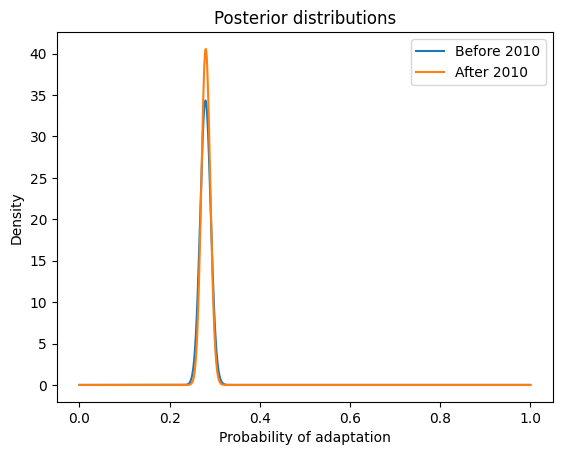

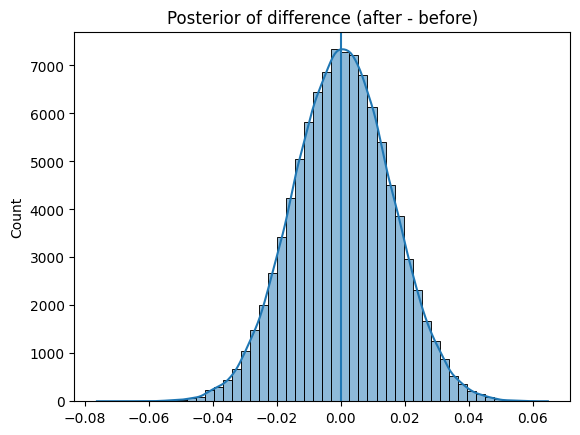

In [11]:
# Posterior distributions
x = np.linspace(0, 1, 1000)

plt.figure()
plt.plot(x, beta.pdf(x, a_before, b_before), label="Before 2010")
plt.plot(x, beta.pdf(x, a_after, b_after), label="After 2010")
plt.title("Posterior distributions")
plt.xlabel("Probability of adaptation")
plt.ylabel("Density")
plt.legend()
plt.show()

# Difference distribution
plt.figure()
sns.histplot(diff, bins=50, kde=True)
plt.axvline(0)
plt.title("Posterior of difference (after - before)")
plt.show()

In [12]:
results = pd.DataFrame({
    "Period": ["Before 2010", "After 2010"],
    "n (films)": [n_before, n_after],
    "k (adaptations)": [k_before, k_after],
    "Proportion": [p_before, p_after]
})

results

,Period,n (films),k (adaptations),Proportion
0,Before 2010,1492,417,0.279491
1,After 2010,2085,584,0.280096


## Interpretation

The posterior means for both periods are nearly identical (approximately 0.28), indicating that the proportion of adaptations has remained stable over time.

The 95% credible intervals for the two periods largely overlap, suggesting no meaningful difference between them.

Furthermore, the probability that the adaptation rate after 2010 is higher than before 2010 is approximately 0.514, which is very close to 0.5. This indicates that there is no strong evidence in favor of an increase.

Finally, the credible interval for the difference includes zero, confirming that the observed difference is not statistically significant.

Overall, the results suggest that the probability of films being adaptations has not increased after 2010.

## Technical Conclusion

Using a Bayesian Beta–Binomial model, we compared the probability that a film is an adaptation before and after 2010.

The results show that the two probabilities are almost identical, and there is no strong evidence supporting an increase in adaptation rates over time.

Therefore, we fail to reject the null hypothesis and conclude that the proportion of adaptations has remained stable.

## Epistemological Conclusion

This analysis has several limitations.

First, the data comes from Wikidata, which is a collaborative database. The “based on” (P144) property is not always consistently filled, meaning that some adaptations may be misclassified as original works.

Second, more popular or recent films are more likely to have complete metadata, which may introduce a bias.

Finally, the analysis assumes that all films are equally representative of the industry, which may not be the case.

Future work could include using additional data sources, refining the definition of adaptations, or analyzing trends by genre or country.